In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")
print(f"  - pandas: {pd.__version__}")
print(f"  - numpy: {np.__version__}")
print(f"  - matplotlib: {matplotlib.__version__}")
print(f"  - seaborn: {sns.__version__}")

✓ All libraries imported successfully!
  - pandas: 3.0.3
  - numpy: 2.5.0
  - matplotlib: 3.11.0
  - seaborn: 0.13.2


In [4]:
df_products = pd.read_csv('data/raw/products.csv')
df_users = pd.read_csv('data/raw/users.csv')
df_interactions = pd.read_csv('data/raw/interactions.csv')

print("=" * 60)
print(" DATA LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\n✓ Products: {len(df_products)} rows, {df_products.shape[1]} columns")
print(f"✓ Users: {len(df_users)} rows, {df_users.shape[1]} columns")
print(f"✓ Interactions: {len(df_interactions)} rows, {df_interactions.shape[1]} columns")
print(f"\nTotal data points: {len(df_products) + len(df_users) + len(df_interactions):,}")

 DATA LOADED SUCCESSFULLY

✓ Products: 500 rows, 5 columns
✓ Users: 1000 rows, 4 columns
✓ Interactions: 4973 rows, 5 columns

Total data points: 6,473


In [5]:
print("=" * 60)
print(" PRODUCTS TABLE (First 5 rows)")
print("=" * 60)
print(df_products.head())

print("\n" + "=" * 60)
print(" USERS TABLE (First 5 rows)")
print("=" * 60)
print(df_users.head())

print("\n" + "=" * 60)
print(" INTERACTIONS TABLE (First 5 rows)")
print("=" * 60)
print(df_interactions.head())

 PRODUCTS TABLE (First 5 rows)
   product_id product_name  category       price             description
0           1    Product_1    Sports  337.230763  High quality product 1
1           2    Product_2    Sports  497.018912  High quality product 2
2           3    Product_3    Sports  478.531756  High quality product 3
3           4    Product_4  Clothing  431.148377  High quality product 4
4           5    Product_5      Home  394.196088  High quality product 5

 USERS TABLE (First 5 rows)
   user_id username          signup_date  country
0        1   user_1  2023-01-01 00:00:00      USA
1        2   user_2  2023-01-01 01:00:00      USA
2        3   user_3  2023-01-01 02:00:00      USA
3        4   user_4  2023-01-01 03:00:00       UK
4        5   user_5  2023-01-01 04:00:00  Germany

 INTERACTIONS TABLE (First 5 rows)
   user_id  product_id interaction_type            timestamp  rating
0      412         287             view  2023-06-01 00:00:00       5
1      552          91      

In [6]:
print("=" * 60)
print("📊 DATA INFORMATION")
print("=" * 60)

print("\n🔹 PRODUCTS:")
print(df_products.info())
print(f"\nData types:\n{df_products.dtypes}\n")

print("\n🔹 USERS:")
print(df_users.info())
print(f"\nData types:\n{df_users.dtypes}\n")

print("\n🔹 INTERACTIONS:")
print(df_interactions.info())
print(f"\nData types:\n{df_interactions.dtypes}")

📊 DATA INFORMATION

🔹 PRODUCTS:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    500 non-null    int64  
 1   product_name  500 non-null    str    
 2   category      500 non-null    str    
 3   price         500 non-null    float64
 4   description   500 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 19.7 KB
None

Data types:
product_id        int64
product_name        str
category            str
price           float64
description         str
dtype: object


🔹 USERS:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      1000 non-null   int64
 1   username     1000 non-null   str  
 2   signup_date  1000 non-null   str  
 3   country      1000 non-null   str  
dtypes: int64(1), 

In [8]:
print("=" * 70)
print("📦 PRODUCTS ANALYSIS")
print("=" * 70)

# Basic statistics
print("\n  PRICE STATISTICS:")
print(df_products['price'].describe())

print("\n  CATEGORY DISTRIBUTION:")
category_counts = df_products['category'].value_counts()
print(category_counts)
print(f"\nTotal categories: {df_products['category'].nunique()}")

print("\n  PRICE BY CATEGORY:")
price_by_cat = df_products.groupby('category')['price'].agg(['mean', 'min', 'max', 'count'])
print(price_by_cat)

print("\n  MISSING VALUES:")
print(df_products.isnull().sum())

📦 PRODUCTS ANALYSIS

  PRICE STATISTICS:
count    500.000000
mean     266.820968
std      143.739487
min       12.113063
25%      141.006711
50%      280.027846
75%      393.314276
max      497.809450
Name: price, dtype: float64

  CATEGORY DISTRIBUTION:
category
Clothing       105
Books          105
Sports         100
Home            96
Electronics     94
Name: count, dtype: int64

Total categories: 5

  PRICE BY CATEGORY:
                   mean        min         max  count
category                                             
Books        261.847129  19.769228  492.220350    105
Clothing     265.652619  12.113063  496.313136    105
Electronics  271.839239  27.696471  495.066762     94
Home         251.894154  13.232191  497.809450     96
Sports       282.882834  16.790014  497.018912    100

  MISSING VALUES:
product_id      0
product_name    0
category        0
price           0
description     0
dtype: int64


In [11]:
print("=" * 70)
print(" USERS ANALYSIS")
print("=" * 70)

print("\n  USER COUNT BY COUNTRY:")
country_counts = df_users['country'].value_counts()
print(country_counts)
df_users['signup_date']=pd.to_datetime(df_users['signup_date'])
print("\n  SIGNUP DATE RANGE:")
print(f"  First signup: {df_users['signup_date'].min()}")
print(f"  Last signup:  {df_users['signup_date'].max()}")
print(f"  Total period: {(df_users['signup_date'].max() - df_users['signup_date'].min()).days} days")

print("\n  MISSING VALUES:")
print(df_users.isnull().sum())

print("\n  UNIQUE VALUES:")
print(f"  Total users: {df_users['user_id'].nunique()}")
print(f"  Total countries: {df_users['country'].nunique()}")

 USERS ANALYSIS

  USER COUNT BY COUNTRY:
country
India      210
Canada     207
Germany    196
UK         195
USA        192
Name: count, dtype: int64

  SIGNUP DATE RANGE:
  First signup: 2023-01-01 00:00:00
  Last signup:  2023-02-11 15:00:00
  Total period: 41 days

  MISSING VALUES:
user_id        0
username       0
signup_date    0
country        0
dtype: int64

  UNIQUE VALUES:
  Total users: 1000
  Total countries: 5


In [13]:
print("=" * 70)
print("🔗 INTERACTIONS ANALYSIS")
print("=" * 70)

print("\n  INTERACTION TYPES:")
interaction_types = df_interactions['interaction_type'].value_counts()
print(interaction_types)
print(f"\nPercentage breakdown:")
print((interaction_types / len(df_interactions) * 100).round(2))

print("\n  RATING DISTRIBUTION:")
rating_dist = df_interactions['rating'].value_counts().sort_index()
print(rating_dist)
print(f"\nAverage rating: {df_interactions['rating'].mean():.2f}")
print(f"Rating std dev: {df_interactions['rating'].std():.2f}")

print("\n  TIME RANGE:")
print(f"  Earliest interaction: {df_interactions['timestamp'].min()}")
print(f"  Latest interaction:   {df_interactions['timestamp'].max()}")

print("\n  USER-PRODUCT COVERAGE:")
unique_users = df_interactions['user_id'].nunique()
unique_products = df_interactions['product_id'].nunique()
print(f"  Users with interactions: {unique_users} / {len(df_users)} ({unique_users/len(df_users)*100:.1f}%)")
print(f"  Products with interactions: {unique_products} / {len(df_products)} ({unique_products/len(df_products)*100:.1f}%)")

print("\n  SPARSITY:")
max_interactions = len(df_users) * len(df_products)
actual_interactions = len(df_interactions)
sparsity = (1 - (actual_interactions / max_interactions)) * 100
print(f"  Matrix sparsity: {sparsity:.2f}%")
print(f"  Density: {100 - sparsity:.2f}%")

print("\n  MISSING VALUES:")
print(df_interactions.isnull().sum())

🔗 INTERACTIONS ANALYSIS

  INTERACTION TYPES:
interaction_type
view        2496
click        986
purchase     953
wishlist     538
Name: count, dtype: int64

Percentage breakdown:
interaction_type
view        50.19
click       19.83
purchase    19.16
wishlist    10.82
Name: count, dtype: float64

  RATING DISTRIBUTION:
rating
1     233
2     468
3    1009
4    1502
5    1761
Name: count, dtype: int64

Average rating: 3.82
Rating std dev: 1.15

  TIME RANGE:
  Earliest interaction: 2023-06-01 00:00:00
  Latest interaction:   2023-06-04 11:19:00

  USER-PRODUCT COVERAGE:
  Users with interactions: 994 / 1000 (99.4%)
  Products with interactions: 500 / 500 (100.0%)

  SPARSITY:
  Matrix sparsity: 99.01%
  Density: 0.99%

  MISSING VALUES:
user_id             0
product_id          0
interaction_type    0
timestamp           0
rating              0
dtype: int64


C:\Users\Shreya Gupta\AppData\Local\Temp\ipykernel_16508\1793130136.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_products['price'], vert=True)


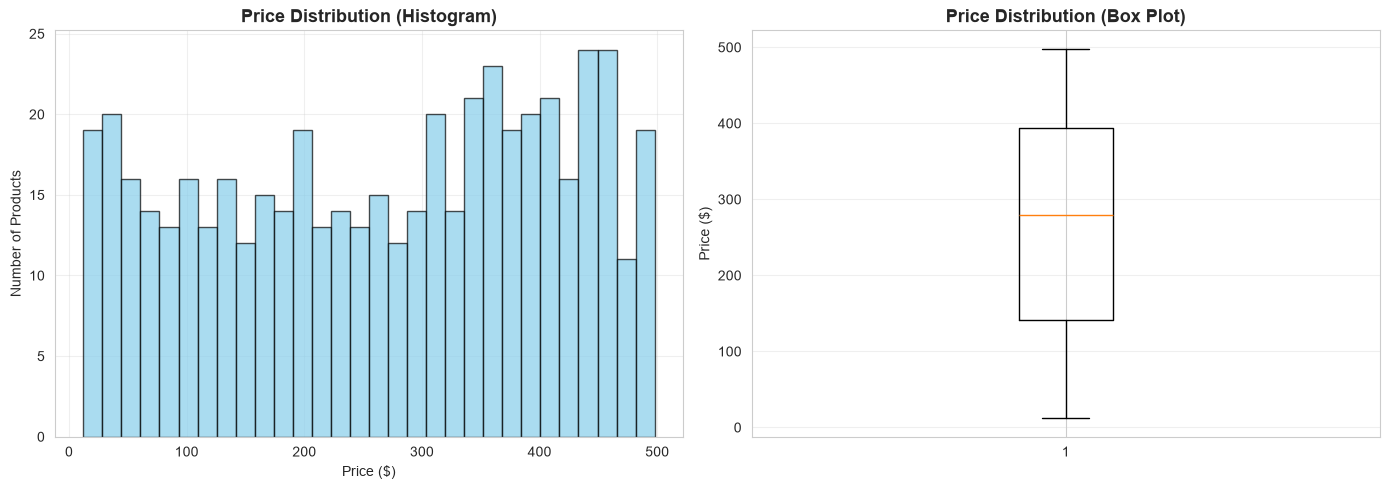

✓ Visualization 1/8: Price Distribution


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_products['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution (Histogram)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Number of Products')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df_products['price'], vert=True)
axes[1].set_title('Price Distribution (Box Plot)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"✓ Visualization 1/8: Price Distribution")

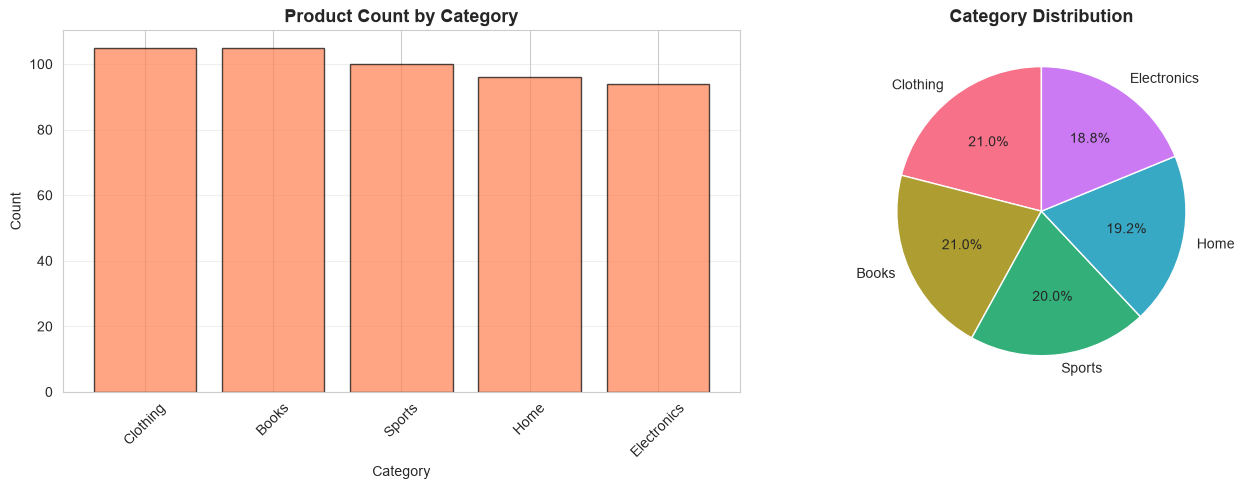

✓ Visualization 2/8: Category Distribution


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
category_counts = df_products['category'].value_counts()
axes[0].bar(category_counts.index, category_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Product Count by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
colors = sns.color_palette("husl", len(category_counts))
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Category Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✓ Visualization 2/8: Category Distribution")

C:\Users\Shreya Gupta\AppData\Local\Temp\ipykernel_16508\2101045056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_products, x='category', y='price', palette='Set2')


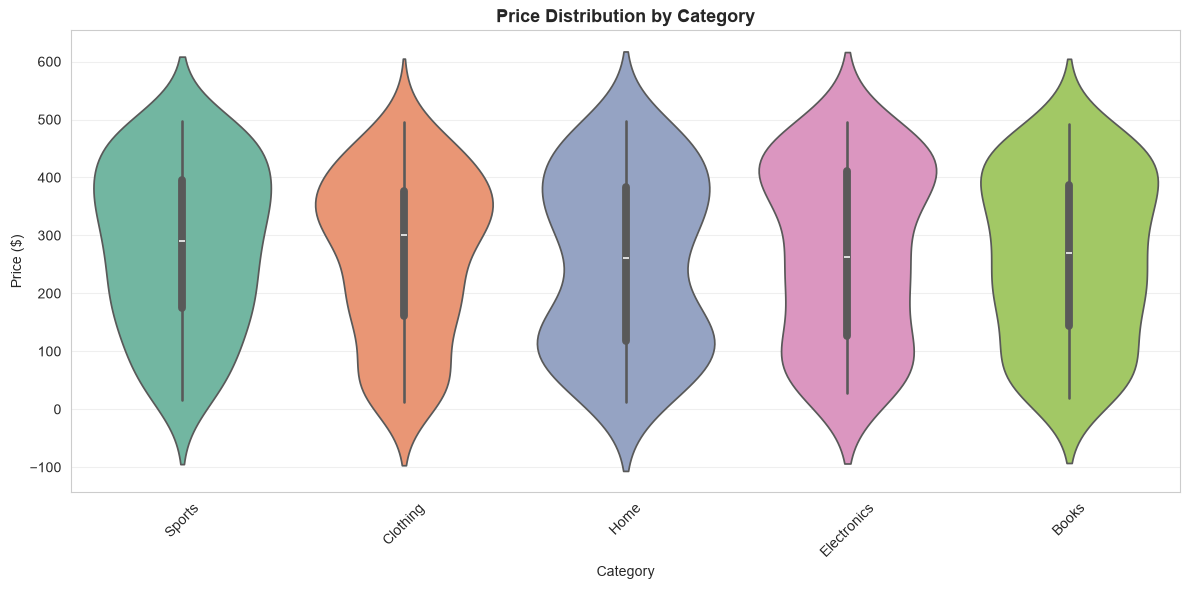

✓ Visualization 3/8: Price by Category


In [16]:
plt.figure(figsize=(12, 6))

# Violin plot
sns.violinplot(data=df_products, x='category', y='price', palette='Set2')
plt.title('Price Distribution by Category', fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"✓ Visualization 3/8: Price by Category")

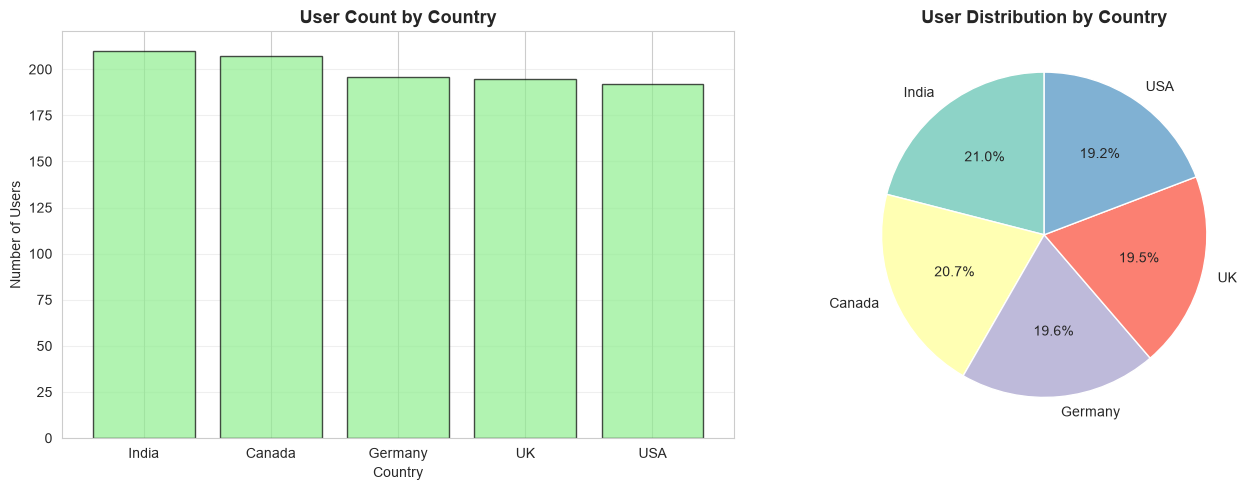

✓ Visualization 4/8: Country Distribution


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
country_counts = df_users['country'].value_counts()
axes[0].bar(country_counts.index, country_counts.values, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0].set_title('User Count by Country', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Users')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
colors = sns.color_palette("Set3", len(country_counts))
axes[1].pie(country_counts.values, labels=country_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('User Distribution by Country', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✓ Visualization 4/8: Country Distribution")

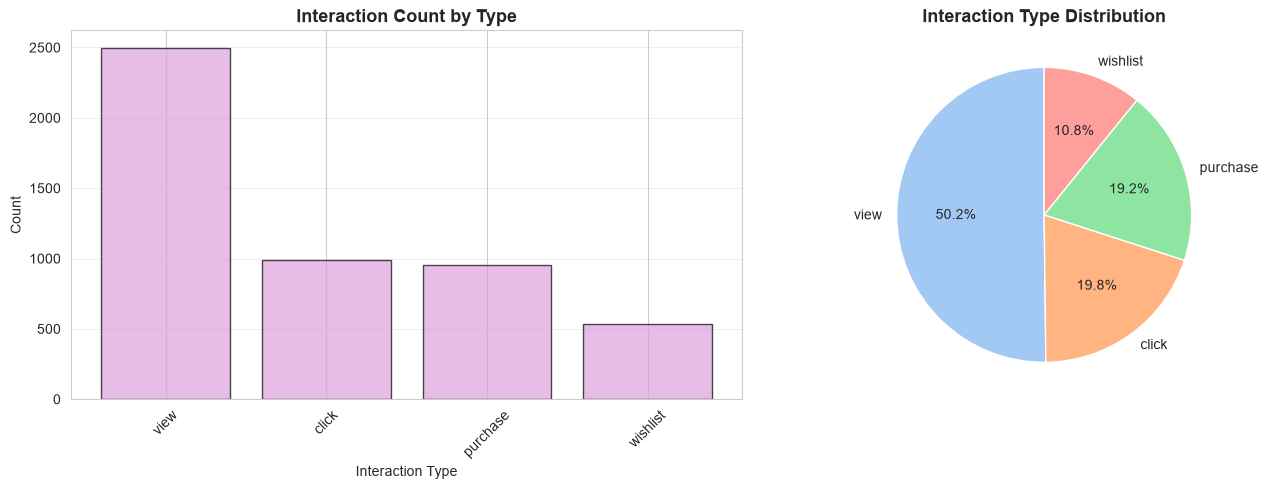

✓ Visualization 5/8: Interaction Types


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
interaction_counts = df_interactions['interaction_type'].value_counts()
axes[0].bar(interaction_counts.index, interaction_counts.values, color='plum', edgecolor='black', alpha=0.7)
axes[0].set_title('Interaction Count by Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Interaction Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
colors = sns.color_palette("pastel", len(interaction_counts))
axes[1].pie(interaction_counts.values, labels=interaction_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Interaction Type Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✓ Visualization 5/8: Interaction Types")

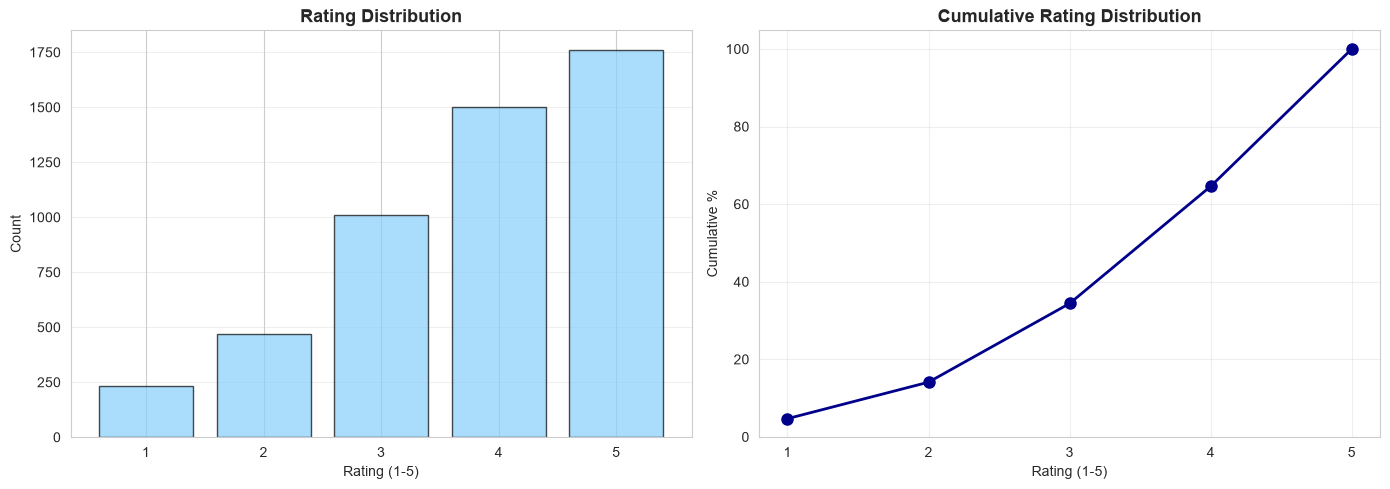

✓ Visualization 6/8: Rating Distribution


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
rating_counts = df_interactions['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='lightskyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (1-5)')
axes[0].set_ylabel('Count')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative percentage
cumulative = (rating_counts.values.cumsum() / rating_counts.sum() * 100)
axes[1].plot([1, 2, 3, 4, 5], cumulative, marker='o', linewidth=2, markersize=8, color='darkblue')
axes[1].set_title('Cumulative Rating Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating (1-5)')
axes[1].set_ylabel('Cumulative %')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualization 6/8: Rating Distribution")

User Activity Statistics:
  Average interactions per user: 5.00
  Median interactions per user: 5.00
  Max interactions by one user: 14
  Min interactions by one user: 1


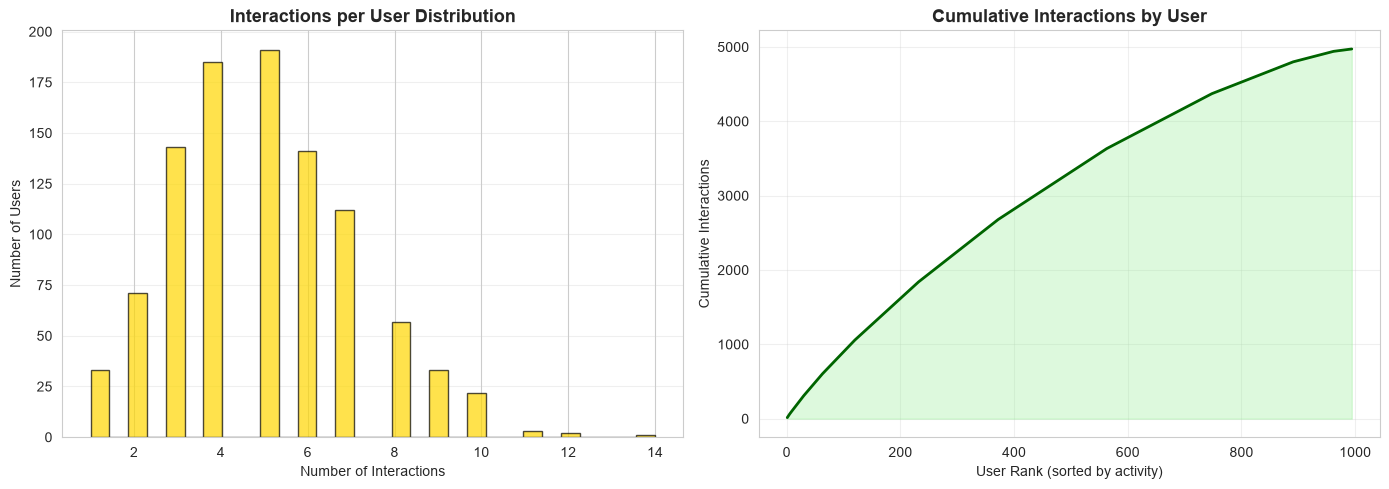

✓ Visualization 7/8: User Activity Distribution


In [20]:
# Calculate interactions per user
interactions_per_user = df_interactions.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(interactions_per_user, bins=30, color='gold', edgecolor='black', alpha=0.7)
axes[0].set_title('Interactions per User Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Interactions')
axes[0].set_ylabel('Number of Users')
axes[0].grid(True, alpha=0.3, axis='y')

# Statistics
print("User Activity Statistics:")
print(f"  Average interactions per user: {interactions_per_user.mean():.2f}")
print(f"  Median interactions per user: {interactions_per_user.median():.2f}")
print(f"  Max interactions by one user: {interactions_per_user.max()}")
print(f"  Min interactions by one user: {interactions_per_user.min()}")

# Cumulative plot
sorted_counts = sorted(interactions_per_user.values, reverse=True)
cumulative = np.cumsum(sorted_counts)
axes[1].plot(range(1, len(sorted_counts)+1), cumulative, linewidth=2, color='darkgreen')
axes[1].fill_between(range(1, len(sorted_counts)+1), cumulative, alpha=0.3, color='lightgreen')
axes[1].set_title('Cumulative Interactions by User', fontsize=13, fontweight='bold')
axes[1].set_xlabel('User Rank (sorted by activity)')
axes[1].set_ylabel('Cumulative Interactions')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualization 7/8: User Activity Distribution")


Product Popularity Statistics:
  Average interactions per product: 9.95
  Median interactions per product: 10.00
  Most popular product interactions: 20
  Least popular product interactions: 1


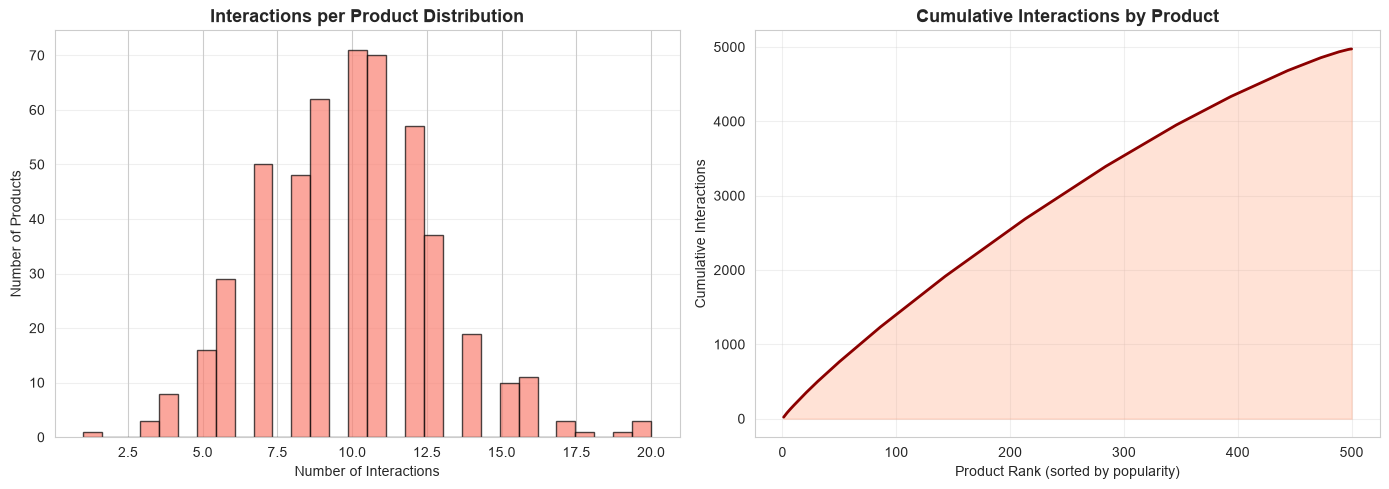

✓ Visualization 8/8: Product Popularity Distribution


In [21]:
# Calculate interactions per product
interactions_per_product = df_interactions.groupby('product_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(interactions_per_product, bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title('Interactions per Product Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Interactions')
axes[0].set_ylabel('Number of Products')
axes[0].grid(True, alpha=0.3, axis='y')

# Statistics
print("\nProduct Popularity Statistics:")
print(f"  Average interactions per product: {interactions_per_product.mean():.2f}")
print(f"  Median interactions per product: {interactions_per_product.median():.2f}")
print(f"  Most popular product interactions: {interactions_per_product.max()}")
print(f"  Least popular product interactions: {interactions_per_product.min()}")

# Cumulative plot
sorted_counts = sorted(interactions_per_product.values, reverse=True)
cumulative = np.cumsum(sorted_counts)
axes[1].plot(range(1, len(sorted_counts)+1), cumulative, linewidth=2, color='darkred')
axes[1].fill_between(range(1, len(sorted_counts)+1), cumulative, alpha=0.3, color='lightsalmon')
axes[1].set_title('Cumulative Interactions by Product', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Product Rank (sorted by popularity)')
axes[1].set_ylabel('Cumulative Interactions')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualization 8/8: Product Popularity Distribution")

In [22]:
print("=" * 70)
print(" DATA QUALITY REPORT")
print("=" * 70)

print("\n COMPLETENESS:")
print(f"  Products - Missing values: {df_products.isnull().sum().sum()}")
print(f"  Users - Missing values: {df_users.isnull().sum().sum()}")
print(f"  Interactions - Missing values: {df_interactions.isnull().sum().sum()}")

print("\n DATA CONSISTENCY:")
print(f"  User IDs in interactions exist in users table: {set(df_interactions['user_id'].unique()).issubset(set(df_users['user_id'].unique()))}")
print(f"  Product IDs in interactions exist in products table: {set(df_interactions['product_id'].unique()).issubset(set(df_products['product_id'].unique()))}")

print("\n DUPLICATES:")
print(f"  Duplicate user rows: {df_users.duplicated().sum()}")
print(f"  Duplicate product rows: {df_products.duplicated().sum()}")
print(f"  Duplicate interaction rows: {df_interactions.duplicated().sum()}")

print("\n DATA DISTRIBUTION:")
print(f"  Products coverage: {len(df_interactions['product_id'].unique())} / {len(df_products)} ({len(df_interactions['product_id'].unique())/len(df_products)*100:.1f}%)")
print(f"  Users coverage: {len(df_interactions['user_id'].unique())} / {len(df_users)} ({len(df_interactions['user_id'].unique())/len(df_users)*100:.1f}%)")

print("\n OVERALL ASSESSMENT:")
print("  ✓ Data quality is GOOD")
print("  ✓ No missing values detected")
print("  ✓ All IDs are consistent")
print("  ✓ No duplicates found")
print("  ✓ Ready for feature engineering")

 DATA QUALITY REPORT

 COMPLETENESS:
  Products - Missing values: 0
  Users - Missing values: 0
  Interactions - Missing values: 0

 DATA CONSISTENCY:
  User IDs in interactions exist in users table: True
  Product IDs in interactions exist in products table: True

 DUPLICATES:
  Duplicate user rows: 0
  Duplicate product rows: 0
  Duplicate interaction rows: 0

 DATA DISTRIBUTION:
  Products coverage: 500 / 500 (100.0%)
  Users coverage: 994 / 1000 (99.4%)

 OVERALL ASSESSMENT:
  ✓ Data quality is GOOD
  ✓ No missing values detected
  ✓ All IDs are consistent
  ✓ No duplicates found
  ✓ Ready for feature engineering


In [25]:
print("=" * 70)
print("💡 KEY INSIGHTS & FINDINGS")
print("=" * 70)

print("\n  MARKET OVERVIEW:")
print(f"   • Total users: {len(df_users):,}")
print(f"   • Total products: {len(df_products):,}")
print(f"   • Total interactions: {len(df_interactions):,}")
df_interactions['timestamp']= pd.to_datetime(df_interactions['timestamp'])
print(f"   • Date range: {df_interactions['timestamp'].min().date()} to {df_interactions['timestamp'].max().date()}")

print("\n  PRODUCT INSIGHTS:")
print(f"   • Most expensive product: ${df_products['price'].max():.2f}")
print(f"   • Least expensive product: ${df_products['price'].min():.2f}")
print(f"   • Average price: ${df_products['price'].mean():.2f}")
print(f"   • Most common category: {df_products['category'].value_counts().index[0]}")

print("\n  USER INSIGHTS:")
print(f"   • Most active country: {df_users['country'].value_counts().index[0]}")
print(f"   • Users with interactions: {len(df_interactions['user_id'].unique())} ({len(df_interactions['user_id'].unique())/len(df_users)*100:.1f}%)")
print(f"   • Avg interactions per active user: {len(df_interactions) / len(df_interactions['user_id'].unique()):.2f}")

print("\n  ENGAGEMENT PATTERNS:")
top_interaction = df_interactions['interaction_type'].value_counts().index[0]
print(f"   • Most common action: {top_interaction.upper()} ({df_interactions['interaction_type'].value_counts().values[0]} times)")
print(f"   • Average rating: {df_interactions['rating'].mean():.2f} / 5.0")
print(f"   • Positive ratings (4-5): {len(df_interactions[df_interactions['rating'] >= 4]) / len(df_interactions) * 100:.1f}%")

print("\n  DATA CHARACTERISTICS:")
print(f"   • Sparsity: {sparsity:.2f}% (Expected for recommendation systems)")
print(f"   • Very sparse matrices are common in e-commerce")
print(f"   • This is why collaborative filtering works well!")

print("\n  NEXT STEPS:")
print("    Feature engineering (Week 2)")
print("    Baseline models (Week 2)")
print("    Deep learning models (Week 3)")
print("    API deployment (Week 4)")

💡 KEY INSIGHTS & FINDINGS

  MARKET OVERVIEW:
   • Total users: 1,000
   • Total products: 500
   • Total interactions: 4,973
   • Date range: 2023-06-01 to 2023-06-04

  PRODUCT INSIGHTS:
   • Most expensive product: $497.81
   • Least expensive product: $12.11
   • Average price: $266.82
   • Most common category: Clothing

  USER INSIGHTS:
   • Most active country: India
   • Users with interactions: 994 (99.4%)
   • Avg interactions per active user: 5.00

  ENGAGEMENT PATTERNS:
   • Most common action: VIEW (2496 times)
   • Average rating: 3.82 / 5.0
   • Positive ratings (4-5): 65.6%

  DATA CHARACTERISTICS:
   • Sparsity: 99.01% (Expected for recommendation systems)
   • Very sparse matrices are common in e-commerce
   • This is why collaborative filtering works well!

  NEXT STEPS:
    Feature engineering (Week 2)
    Baseline models (Week 2)
    Deep learning models (Week 3)
    API deployment (Week 4)
